## Signals

Signals are representations of physical processes captured by sensors. For instance, this figure shows the average temperature captured by an array of sensors across different global locations, measured daily throughout the year.


<div style="text-align: center;">
<img src='attachment:c553417d-c38b-4dce-a168-ba076a471295.png', width=400, height=400>
</div>

When measuring a biological system, these signals (biosignals) measure the different processes that occur during the function (normal or abnormal) of the organism. These signals act as indicators of physiological states and bodily functions.

It is important to understand that biosignals are a representation of the biological process that is being measured; they do not fully represent or characterize the functioning of the biological system being measured. 


For instance, **muscle contraction** is a complex process that involves electrochemical interactions. Muscle contraction is typically measured using electromyography, which quantifies the change in voltage (electrical component) across the muscle surface. Thus, the biosignal commonly used to quantify muscle contraction only measures one aspect of the biological process. 


### Common biosignals
- Electromyography (EMG): Measurement of electrical activity during muscle contraction.
- Photoplethysmography (PPG): Measurement of blood volume changes in the microvascular tissue, commonly used to monitor heart rate and oxygen saturation.
- Electroencephalogram (EEG): Measurement of the brain's spontaneous electrical activity, measured using electrodes placed on the scalp. These signals represent post-synaptic potentials of neurons.
- Electrocardiogram (ECG): Measurement of the heart's electrical activity over time.
- Electrodermal Activity (EAD): Measurement of sweat gland activity—controlled by the sympathetic nervous system—to indicate physiological arousal, stress, or emotional intensity
- Inertial Measurement Units (IMUs): Measurement of 3D acceleration and angular velocity, which are used to track human movement


### Noise

Biosignals typically emerge from sources deep inside the human body. Thus, these signals are small and are captured with sensitive sensors that must amplify the signal so that it can be interpreted. During the measurement process, it is (VERY) common to capture exogenous signals not related to the biological process. These signals are called noise, and they are combined with the biosignal at the origin, so it is difficult to separate/distinguish between the desired signal and the noise. 

Common sources of noise include:

- *Power line*: Electronic measurement systems capture a signal that originates from the power line. The signal is a sinusoidal with a 50 Hz or 60 Hz frequency (60Hz in America, 50Hz in most other countries). This figure shows an example of an EMG signal with power line interference.
<div style="text-align: center;">
<img src='attachment:6ee2fb9a-47c3-429e-a108-bf24ab3d0179.png' alt='Global Temp', width=600, height=200>
</div>

Most modern measurement systems can mitigate power line interferences and minimize their effect on the measured biosignal. 

- *Movement artifacts*: Movement can interfere with the sensors capturing the biosignal and render the signal unusable. This figure shows an example of a PPG signal with motion artifacts.
<div style="text-align: center;">
<img src='attachment:1e324d25-f635-4953-9cb5-a486a44405a3.png' alt='Global Temp', width=600, height=200>
</div>

Modern biosensing systems typically include movement sensors to mitigate the effect of motion (or at least indicate the presence of these artifacts in the signal).

- *Other physiological sources*: Most sources of biosignals are deep within the body, making it difficult to separate the signals provided by different sources. This figure shows an example of an EMG signal captured from the chest muscles that includes undesired measurements of heart activity.
<div style="text-align: center;">
<img src='attachment:862c7cba-55ed-4925-a810-546210e210b0.png' alt='Global Temp', width=600, height=200>
</div> 

- *Random noise*: The electronic equipment used in the sensors induces different sources of electronic random noise, including thermal noise, shot noise, or 1/f noise, that corrupt, mask, or distort the weak biological signals. This noise is observed as random oscillations in the signal. This figure shows an example of an ECG signal with random noise.
<div style="text-align: center;">
<img src='attachment:e8b42fa7-efa9-4fe2-8ed1-c10ecbb6c482.png' alt='Global Temp', width=400, height=150>
</div> 



### Filtering

Filtering refers to removing some unwanted components of your signal. By filtering your signal, you can enhance the important component while minimizing the *noise*.

There are many techniques for signal filtering, and new filter designs can be developed for specific needs. 

_Note_: Filters can be used to separate different components of a signal; these components are not necessarily noise, it depends on the application. 

- *Median Filter*: A median filter replaces every value in a signal with the median value of a small window around the value.

<div style="text-align: center;">
<img src='attachment:b579b07d-5729-4847-a2f1-e4ad067074fe.png' alt='Median Filter', width=600, height=200>
</div> 

    Step 1: Augment your signal by mirroring the end.
    
<div style="text-align: center;">
<img src='attachment:8b96f2d5-5cc5-4620-9f35-4aea37086af4.png' alt='Median Filter', width=600, height=200>
</div> 

    Step 2: Use the values around a small window and find the median. Store the results
<div style="text-align: center;">
<img src='attachment:68223d3c-f755-4c97-a635-84dcba071658.png' alt='Median Filterp', width=600, height=200>
</div> 

    Step 3: Move the window one step and repeat the process 
<div style="text-align: center;">
<img src='attachment:de0e3569-ed83-4425-9362-701ea29cb783.png' alt='Median Filter', width=600, height=200>
</div> 

    Step 4: Continue until you process all the data in the signal. 
<div style="text-align: center;">
<img src='attachment:dbee2b19-c6f9-4d21-ab3d-8582e82cc9c5.png' alt='Median Filter', width=600, height=200>
</div> 


The resulting signal is smoother than the original. You can adjust the window size to obtain smoother outputs. 



(-3.0, 3.0)

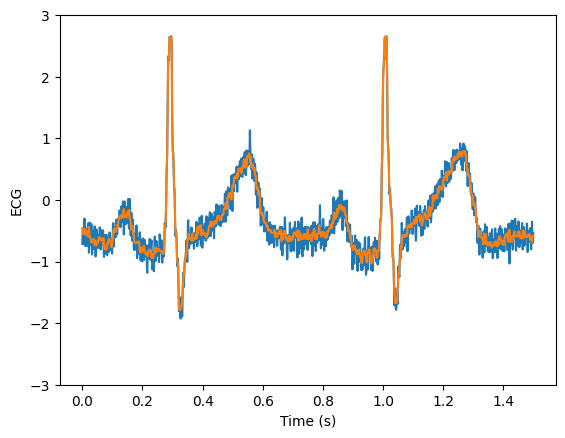

In [1]:
#median filters are already implemented in the scipy library 
import numpy as np
from scipy.signal import medfilt
import matplotlib.pyplot as plt

#load some noisy data captured at 1000 Hz
data=np.loadtxt('data/ecg_hfn.dat')
Fs=1000
time= np.arange(0,len(data)*1/Fs,1/Fs) # time vector
#plot the noisy data
plt.plot(time[0:1500],data[0:1500])
plt.xlabel('Time (s)')
plt.ylabel('EEG')
plt.ylim([-3,3])

### Apply a median filter with a window of size 5
window_size = 9
filtered_signal = medfilt(data,window_size)
plt.plot(time[0:1500],filtered_signal[0:1500])
plt.xlabel('Time (s)')
plt.ylabel('ECG')
plt.ylim([-3,3])


## Activity

Change the window size to 7,15,35,51, and 99. What happens to the filtered signal? 

⚠️ Important:
Filtering does NOT recover the “true” signal.
It removes components based on assumptions about what is noise.

Poor filter choices can:
- Remove real movement features
- Shift timing
- Alter peak values


- *Savitzky-Golay filter*:  A Savitzky-Golay (SG) filter replaces every value in a signal with the value derived from a low-order polynomial fitter on a small window around the value.

<div style="text-align: center;">
<img src='attachment:f61da06f-493c-411b-a520-f00d78c2a646.png' alt='Median Filter', width=600, height=200>
</div> 

    Step 1: Augment your signal by mirroring the end.
    
<div style="text-align: center;">
<img src='attachment:02da3bca-6235-4640-b954-d3b27405c4c9.png' alt='Median Filter', width=600, height=200>
</div> 


    Step 2: Use the values around a small window and fit a low-order polynomial (usually order 2 or 3).
<div style="text-align: center;">
<img src='attachment:20bab32a-1703-437b-b3d0-f3f5a6201a63.png' alt='Median Filterp', width=600, height=200>
</div> 


    Step 3: Evaluate the polynomial at the desired index and store the results
<div style="text-align: center;">
<img src='attachment:1ad2d052-6cd3-4b46-8908-0c85359b143c.png' alt='Median Filterp', width=600, height=200>
</div> 


    Step 4: Move the window one step and repeat the process 
<div style="text-align: center;">
<img src='attachment:72aecc1d-9e2b-4a5b-b9b9-f7b69b697c1b.png' alt='Median Filterp', width=600, height=200>
</div> 

    Step 5: Continue until you process all the data in the signal.
<div style="text-align: center;">
<img src='attachment:874bb811-eb70-46df-b842-0606ca889ef0.png' alt='Median Filterp', width=600, height=200>
</div> 


The resulting signal is smoother than the original. You can adjust the window size and polynomial order to obtain smoother outputs. 

(-3.0, 3.0)

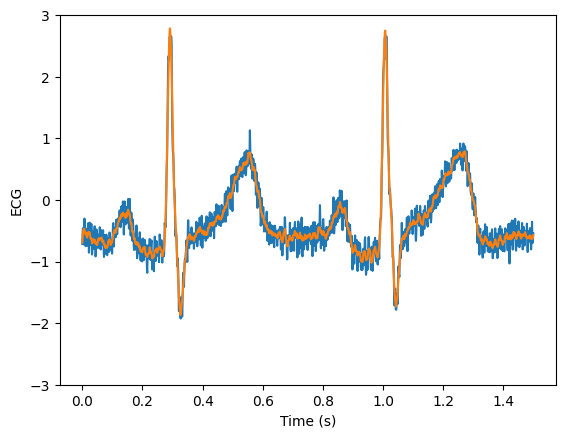

In [2]:
#SG filters are already implemented in the scipy library 
import numpy as np
from scipy.signal import savgol_filter
import matplotlib.pyplot as plt

#load some noisy data captured at 1000 Hz
data=np.loadtxt('data/ecg_hfn.dat')
Fs=1000
time= np.arange(0,len(data)*1/Fs,1/Fs) # time vector
#plot the noisy data
plt.plot(time[0:1500],data[0:1500])
plt.xlabel('Time (s)')
plt.ylabel('EEG')
plt.ylim([-3,3])

### Apply a SG filter with a window of size 5 and polynomial order 2 
filtered_signal = savgol_filter(data, 19, 3)
plt.plot(time[0:1500],filtered_signal[0:1500])
plt.xlabel('Time (s)')
plt.ylabel('ECG')
plt.ylim([-3,3])

## Activity

a) Change the window size to 7,15,35,51, and 99. What happens to the filtered signal? 
b) for a window size of 35, change the polynomial order to 4,8,16,32. What happens to the filtered signal? 

- *Ensemble filter*:  An ensemble filter uses multiple repetitions of the same process to identify an average across repetitions. Ensemble filters are ideal for signals that represent the same process recorded multiple times.

<div style="text-align: center;">
<img src='attachment:95c2cb38-1549-4af2-8d31-b331db3698da.png' alt='Median Filterp', width=600, height=200>
</div> 

The resulting signal is smoother than the original. You can adjust the number of elements in the ensemble to obtain smoother outputs. 

- *Frequency domain filtering*:

**The Fourier Theorem**
Any reasonably well-behaved periodic function or signal can be expressed as an infinite sum of simple sine waves (harmonics) with specific amplitudes and frequencies. 


<div style="text-align: center;">
<img src='Fourier_transform_time_and_frequency_domains.gif' alt='Median Filterp', width=600, height=600>
</div> 

Frequency domain filtering refers to eliminating some of those frequency components. Once those frequency components are removed, it is possible to reconstruct a new signal that does not include the undesired components. There are different types of filters depending on the components being removed from the signal:

- *Frequency domain filtering*:
  
  - Low-Pass Filter: Low-Pass filters remove frequency components above a certain threshold, leaving only the low-frequency components of the signal. Low-Pass filters help to smooth a signal.
<div style="text-align: center;">
<img src='attachment:290c41cf-6e42-472f-bb02-c7c858d44edf.png' alt='Median Filterp', width=300, height=200>
</div> 
  - High-Pass Filter: High-Pass filters remove frequency components below a certain threshold, leaving only the high-frequency components of the signal. High-Pass filters help to detrend a signal. 
<div style="text-align: center;">
<img src='attachment:08bc19b1-a800-4366-bd04-3f376591c4e2.png' alt='Median Filterp', width=300, height=200>
</div>  
  - Band-Pass Filter: Band-Pass filters remove frequency components below and above a certain threshold, leaving only the frequency components of the signal within a certain frequency band. Band-Pass filters filters help detrend and smooth signals.
<div style="text-align: center;">
<img src='attachment:16de0459-519b-4b2d-a386-fe12f4d1dce8.png' alt='Median Filterp', width=300, height=200>
</div> 
  - Band-Stop Filter: Band-Stop filters remove frequency components below and above a certain threshold, removing all frequency components of the signal within a certain frequency band. Band-Pass filters help remove specific components of a signal. 
<div style="text-align: center;">
<img src='attachment:6db4ef04-3d2d-4672-8826-bde40274c287.png' alt='Median Filterp', width=300, height=200>
</div>
  - Notch Filter: Notch filters remove frequency components with a specific frequency. Nothc filters help remove power-line interference. 
<div style="text-align: center;">
<img src='attachment:ce3514a3-0a4f-4ba2-a461-9244f13f0521.png' alt='Median Filterp', width=300, height=200>
</div>



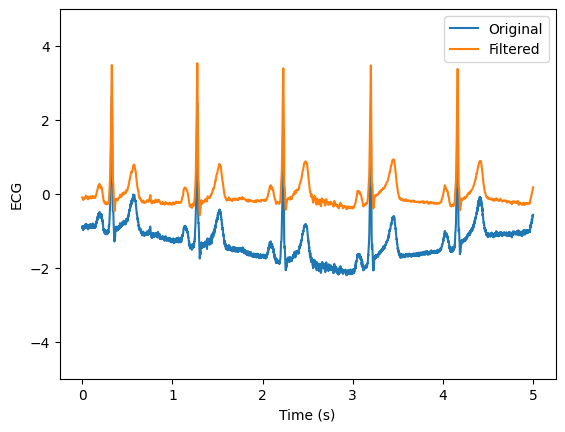

In [19]:
from scipy.signal import butter, filtfilt

data=np.loadtxt( 'data/ecg_lfn.dat' )
Fs=1000
time= np.arange(0,len(data)*1/Fs,1/Fs) # time vector
#plot the noisy data
plt.plot(time[0:5000],data[0:5000], label='Original')
plt.xlabel('Time (s)')
plt.ylabel('ECG')
plt.ylim([-5,5])


#designing and applying a filter with the desired cutoffs. For ECG, we usually want to retain between 0.5 and 100 Hz
low_cf = 0.5 / (Fs/2)
high_cf = 100 / (Fs/2)
b, a = butter(4, [low_cf, high_cf], btype='bandpass') #desing the filter
filtered_signal = filtfilt(b,a,data) #apply the filter
plt.plot(time[0:5000],filtered_signal[0:5000], label='Filtered')
plt.legend();

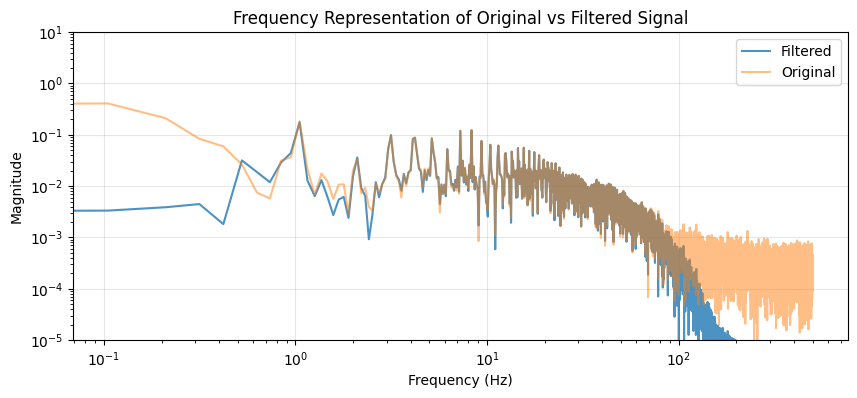

In [20]:
from scipy.signal import periodogram

# Frequency representation (magnitude spectrum) using periodogram

freqs, orig_psd = periodogram(data, fs=Fs, scaling='spectrum')
_, filt_psd = periodogram(filtered_signal, fs=Fs, scaling='spectrum')

# Convert power spectrum to magnitude-like scale
orig_mag = np.sqrt(orig_psd)
filt_mag = np.sqrt(filt_psd)

plt.figure(figsize=(10, 4))
plt.loglog(freqs, filt_mag, label='Filtered', alpha=0.8)
plt.loglog(freqs, orig_mag, label='Original', alpha=0.5)
plt.ylim(10e-6, 10)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.title('Frequency Representation of Original vs Filtered Signal')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Note: The frequencies to preserve depend on the physiological process being analyzed. We usually remove components below 0.5 Hz to remove undersided trends. 

Rule of thumb:
- Slow, voluntary movement → low frequencies
- Faster movements → higher frequencies
- Noise often dominates above physiological movement frequencies


### Key Takeaways

- Biosignals from human movement are always noisy
- Filtering is a modeling decision, not just a technical step
- Different filters remove different types of noise

**Filter-Specific Insights**

- Median filters are effective for removing spikes and tracking errors
- Ensemble filters exploit repetition to reduce random noise but hide variability
- Low-pass filters preserve slow, voluntary movement while removing high-frequency noise
- High-pass filters remove slow trends but can eliminate meaningful motion
- Band-pass filters isolate specific physiological phenomena (e.g., tremor)

**Frequency-Domain Thinking**

- Movement signals are dominated by low frequencies
- Noise often appears at higher frequencies
- Fourier analysis helps guide filter design, even if filters are applied in time
